# Objective

The objective of this notebook is to clean the Goodreads dataset and prepare it for the recommendation system.

In [3]:
import pandas as pd
import glob
import os

path = '../data/raw/archive' 

all_files = glob.glob(os.path.join(path, "book*.csv"))

df_list = [pd.read_csv(filename) for filename in all_files]

combined_df = pd.concat(df_list, ignore_index=True)

combined_df.to_csv('../data/raw/all_books_combined.csv', index=False)

print("Total number of books:", len(combined_df))

Total number of books: 1850310


In [4]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850310 entries, 0 to 1850309
Data columns (total 21 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Id                     int64  
 1   Name                   object 
 2   RatingDist1            object 
 3   pagesNumber            float64
 4   RatingDist4            object 
 5   RatingDistTotal        object 
 6   PublishMonth           int64  
 7   PublishDay             int64  
 8   Publisher              object 
 9   CountsOfReview         int64  
 10  PublishYear            int64  
 11  Language               object 
 12  Authors                object 
 13  Rating                 float64
 14  RatingDist2            object 
 15  RatingDist5            object 
 16  ISBN                   object 
 17  RatingDist3            object 
 18  Description            object 
 19  Count of text reviews  float64
 20  PagesNumber            float64
dtypes: float64(4), int64(5), object(12)
memory usage: 296.

In [5]:
combined_df.shape

(1850310, 21)

In [6]:
combined_df.head()

,Id,Name,RatingDist1,pagesNumber,RatingDist4,RatingDistTotal,PublishMonth,PublishDay,Publisher,CountsOfReview,...,Language,Authors,Rating,RatingDist2,RatingDist5,ISBN,RatingDist3,Description,Count of text reviews,PagesNumber
0,1,Harry Potter and the Half-Blood Prince (Harry ...,1:9896,652.0,4:556485,total:2298124,16,9,Scholastic Inc.,28062,...,eng,J.K. Rowling,4.57,2:25317,5:1546466,NaN,3:159960,NaN,NaN,NaN
1,2,Harry Potter and the Order of the Phoenix (Har...,1:12455,870.0,4:604283,total:2358637,1,9,Scholastic Inc.,29770,...,eng,J.K. Rowling,4.50,2:37005,5:1493113,0439358078,3:211781,NaN,NaN,NaN
2,3,Harry Potter and the Sorcerer's Stone (Harry P...,1:108202,309.0,4:1513191,total:6587388,1,11,Scholastic Inc,75911,...,eng,J.K. Rowling,4.47,2:130310,5:4268227,NaN,3:567458,NaN,NaN,NaN
3,4,Harry Potter and the Chamber of Secrets (Harry...,1:11896,352.0,4:706082,total:2560657,1,11,Scholastic,244,...,eng,J.K. Rowling,4.42,2:49353,5:1504505,0439554896,3:288821,NaN,NaN,NaN
4,5,Harry Potter and the Prisoner of Azkaban (Harr...,1:10128,435.0,4:630534,total:2610317,1,5,Scholastic Inc.,37093,...,eng,J.K. Rowling,4.57,2:24849,5:1749958,043965548X,3:194848,NaN,NaN,NaN


In [7]:
combined_df.isnull().sum()

Id                             0
Name                           0
RatingDist1                    0
pagesNumber              1015232
RatingDist4                    0
RatingDistTotal                0
PublishMonth                   0
PublishDay                     0
Publisher                  17826
CountsOfReview                 0
PublishYear                    0
Language                 1598488
Authors                        0
Rating                         0
RatingDist2                    0
RatingDist5                    0
ISBN                        5923
RatingDist3                    0
Description               679122
Count of text reviews    1440613
PagesNumber               835078
dtype: int64

In [8]:
missing = (combined_df.isnull().sum() / len(combined_df)) * 100
missing.sort_values(ascending=False)

Language                 86.390281
Count of text reviews    77.857927
pagesNumber              54.868211
PagesNumber              45.131789
Description              36.703147
Publisher                 0.963406
ISBN                      0.320109
Name                      0.000000
Id                        0.000000
RatingDist4               0.000000
RatingDist1               0.000000
PublishMonth              0.000000
RatingDistTotal           0.000000
Authors                   0.000000
PublishYear               0.000000
CountsOfReview            0.000000
PublishDay                0.000000
RatingDist5               0.000000
RatingDist2               0.000000
Rating                    0.000000
RatingDist3               0.000000
dtype: float64

In [9]:
combined_df.columns.tolist()

['Id',
 'Name',
 'RatingDist1',
 'pagesNumber',
 'RatingDist4',
 'RatingDistTotal',
 'PublishMonth',
 'PublishDay',
 'Publisher',
 'CountsOfReview',
 'PublishYear',
 'Language',
 'Authors',
 'Rating',
 'RatingDist2',
 'RatingDist5',
 'ISBN',
 'RatingDist3',
 'Description',
 'Count of text reviews',
 'PagesNumber']

In [10]:
combined_df.duplicated().sum()

np.int64(112)

In [11]:
combined_df["Rating"].describe()

count    1.850310e+06
mean     2.894243e+00
std      1.725019e+00
min      0.000000e+00
25%      2.000000e+00
50%      3.680000e+00
75%      4.000000e+00
max      5.000000e+00
Name: Rating, dtype: float64

In [12]:
combined_df["Language"].value_counts()

Language
eng      180338
en-US     21489
fre       16327
ger       11470
en-GB      7767
          ...  
ssw           1
dum           1
tam           1
chp           1
fan           1
Name: count, Length: 124, dtype: int64

<Axes: >

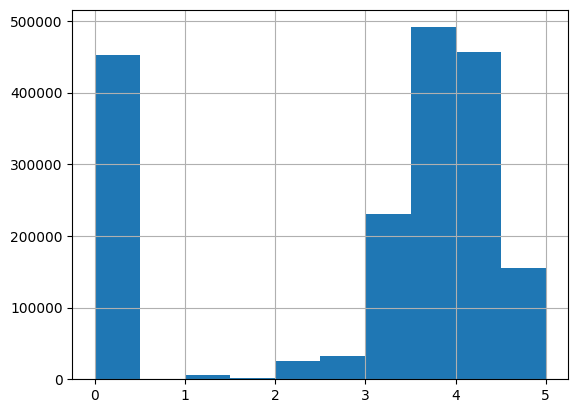

In [13]:
combined_df["Rating"].hist()

<Axes: >

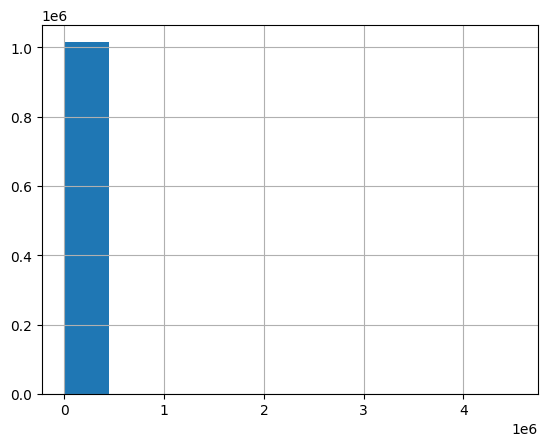

In [14]:
combined_df["PagesNumber"].hist()

In [15]:
combined_df[["PagesNumber", "pagesNumber"]].head(20)

,PagesNumber,pagesNumber
0,NaN,652.0
1,NaN,870.0
2,NaN,309.0
3,NaN,352.0
4,NaN,435.0
5,NaN,734.0
6,NaN,2690.0
7,NaN,152.0
8,NaN,3342.0
9,NaN,815.0


In [16]:
((combined_df["PagesNumber"].isnull()) & (combined_df["pagesNumber"].notnull())).sum()

np.int64(835078)

In [17]:
((combined_df["PagesNumber"].notnull()) & (combined_df["pagesNumber"].isnull())).sum()

np.int64(1015232)

In [18]:
combined_df["PageCount"] = combined_df["PagesNumber"].fillna(combined_df["pagesNumber"])

In [19]:
combined_df["PageCount"].isnull().sum()

np.int64(0)

In [20]:
combined_df[["PagesNumber", "pagesNumber", "PageCount"]].head(20)

,PagesNumber,pagesNumber,PageCount
0,NaN,652.0,652.0
1,NaN,870.0,870.0
2,NaN,309.0,309.0
3,NaN,352.0,352.0
4,NaN,435.0,435.0
5,NaN,734.0,734.0
6,NaN,2690.0,2690.0
7,NaN,152.0,152.0
8,NaN,3342.0,3342.0
9,NaN,815.0,815.0


In [21]:
combined_df = combined_df.drop(columns=["PagesNumber", "pagesNumber"])

In [22]:
columns_to_be_deleted=[            
    'Language',        
    'PublishMonth',    
    'PublishDay',      
    'PublishYear',
    'Count of text reviews',
    'Publisher'
]

combined_df_clean = combined_df.drop(columns=columns_to_be_deleted, errors='ignore')
combined_df_clean.isnull().sum()

Id                      0
Name                    0
RatingDist1             0
RatingDist4             0
RatingDistTotal         0
CountsOfReview          0
Authors                 0
Rating                  0
RatingDist2             0
RatingDist5             0
ISBN                 5923
RatingDist3             0
Description        679122
PageCount               0
dtype: int64

### Data Cleaning - Step 1

- Merged `PagesNumber` and `pagesNumber` into `PageCount`
- Removed duplicate page count columns
- Dropped Language, PublishMonth, PublishDay, PublishYear, Count of text reviews, and Publisher because they were not essential for the first version of the recommendation system. Additionally, Language and Count of text reviews contained a high proportion of missing values.

In [23]:
combined_df_clean.duplicated().sum()

np.int64(112)

In [24]:
combined_df_clean = combined_df_clean.drop_duplicates()

<Axes: >

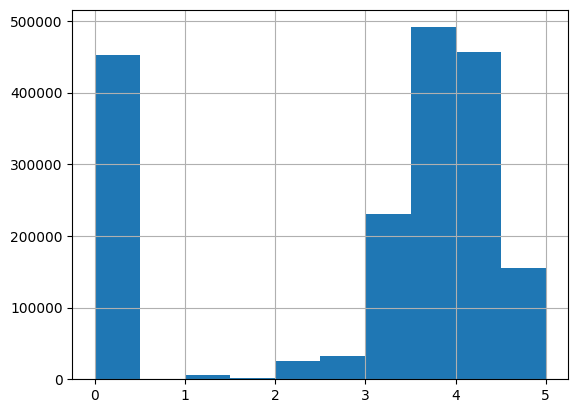

In [25]:
combined_df_clean["Rating"].hist()

<Axes: >

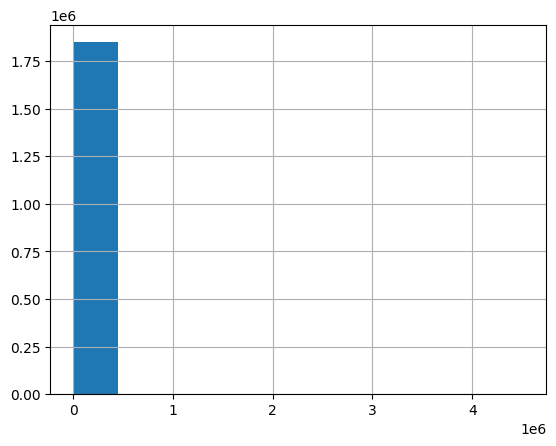

In [26]:
combined_df_clean["PageCount"].hist()

In [27]:
combined_df_clean["PageCount"].describe()

count    1.850198e+06
mean     2.765517e+02
std      5.006171e+03
min      0.000000e+00
25%      1.440000e+02
50%      2.390000e+02
75%      3.380000e+02
max      4.517845e+06
Name: PageCount, dtype: float64

In [28]:
combined_df_clean.nlargest(10, "PageCount")[["Name", "PageCount"]]

,Name,PageCount
358466,"425 Heartwarmin' Expressions For Crafting, Pai...",4517845.0
720047,Another 425 Heartwarmin' Expressions For Craf...,4517845.0
143410,Sholokhov's Tikhii Don: A Commentary In Two Vo...,2254246.0
1020451,Internet Sacred Text Archive 4.0,500000.0
134372,2006 Iran Nuclear Threat � Government And Mili...,205141.0
438765,2006 Essential Guide To The National Security ...,107490.0
1036912,Scholar's Library Series X,100000.0
1812644,Lifelines,80500.0
1723557,Lisa and David/jordi,80300.0
1437405,Gourmet's Menu Cookbk,65224.0


<Axes: >

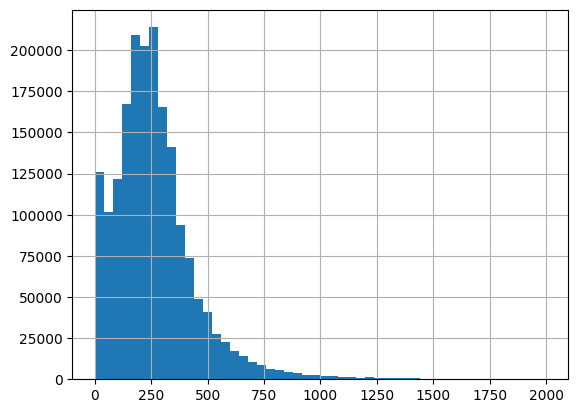

In [29]:
combined_df_clean[
    combined_df_clean["PageCount"] < 2000
]["PageCount"].hist(bins=50)

In [30]:
combined_df_clean[combined_df_clean["PageCount"] > 2000].shape

(2573, 14)

In [31]:
combined_df_clean = combined_df_clean[
    combined_df_clean["PageCount"] <= 2000
]

In [32]:
combined_df_clean["PageCount"].describe()

count    1.847625e+06
mean     2.650630e+02
std      1.905891e+02
min      0.000000e+00
25%      1.440000e+02
50%      2.380000e+02
75%      3.370000e+02
max      2.000000e+03
Name: PageCount, dtype: float64

In [36]:
combined_df_clean['Features'] = combined_df_clean['Name'].fillna('') + " " + \
                                combined_df_clean['Authors'].fillna('') + " " + \
                                combined_df_clean['Description'].fillna('')

combined_df_clean.to_csv("../data/processed/books_clean.csv", index=False)
combined_df_clean.to_pickle("../data/processed/books_clean.pkl")
combined_df_clean.to_pickle("../data/books_metadata.pkl")

# Conclusion

- Removed unnecessary columns
- Merged duplicated page columns
- Removed unrealistic page counts
- Prepared cleaned dataset for the recommendation model